Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Compiling model...
'compile' took 0.082991 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7f4231c79b20>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7f4231c79b20>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss              Test loss               Test metric
0         [4.22e+01, 1.12e-01]    [5.05e+01, 1.12e-01]    []  
1000      [1.28e-03, 5.84e-06]    [1.20e-03, 5.84e-06]    []  
2000      [1.87e-04, 1.66e-07]    [1.78e-04, 1.66e-07]    []  
3000      [7.83e-05, 2.56e-08]    [7.63e-05, 2.56e-08]    []  
4000      [5.27e-05, 2.47e-07]    [5.35e-05, 2.47e-07]    []  
5000      [3.18e-05, 1.66e-08]    [3.19e-05, 1.66e-08]    []  

Best model at step 5000:
  train loss: 3.19e-05
  test loss: 3.19e-

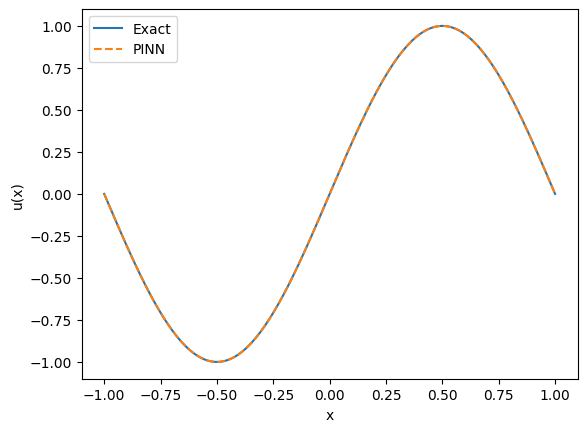

In [ ]:
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# =========================================
# Geometry
# =========================================

geom = dde.geometry.Interval(-1, 1)

# =========================================
# PDE
# =========================================

def pde(x, y):

    dy_xx = dde.grad.hessian(y, x)

    return dy_xx + (np.pi**2) * tf.sin(np.pi * x)

# =========================================
# Boundary Condition
# =========================================

def boundary(x, on_boundary):

    return on_boundary

bc = dde.icbc.DirichletBC(

    geom,

    lambda x: 0,

    boundary

)

# =========================================
# Exact Solution
# =========================================

def exact_solution(x):

    return np.sin(np.pi * x)

# =========================================
# Data
# =========================================

data = dde.data.PDE(

    geom,
    pde,
    bc,

    num_domain=100,
    num_boundary=20,

    #solution=exact_solution,

    num_test=100

)

# =========================================
# Neural Network
# =========================================

net = dde.nn.FNN(

    [1] + [32]*3 + [1],

    "tanh",

    "Glorot normal"

)

# =========================================
# Model
# =========================================

model = dde.Model(data, net)

model.compile(

    "adam",

    lr=0.001

    #metrics=["l2 relative error"]

)

# =========================================
# Training
# =========================================

losshistory, train_state = model.train(

    iterations=5000

)

# =========================================
# Prediction
# =========================================

x = np.linspace(-1,1,200)[:,None]

y_pred = model.predict(x)

y_exact = exact_solution(x)

# =========================================
# Plot
# =========================================

plt.plot(x, y_exact, label="Exact")

plt.plot(x, y_pred, '--', label="PINN")

plt.xlabel("x")

plt.ylabel("u(x)")

plt.legend()

plt.show()

Compiling model...
'compile' took 0.004068 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7f4211c09f80>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7f4211c09f80>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss              Test loss               Test metric
0         [8.06e+02, 1.09e+00]    [7.71e+02, 1.09e+00]    []  
1000      [1.03e-01, 1.44e-03]    [1.01e-01, 1.44e-03]    []  
2000      [8.17e-03, 3.41e-05]    [8.40e-03, 3.41e-05]    []  
3000      [1.42e-03, 5.27e-06]    [1.72e-03, 5.27e-06]    []  
4000      [8.60e-04, 1.69e-06]    [1.08e-03, 1.69e-06]    []  
5000      [5.64e-04, 4.10e-07]    [7.30e-04, 4.10e-07]    []  

Best model at step 5000:
  train loss: 5.64e-04
  test loss: 7.30e-

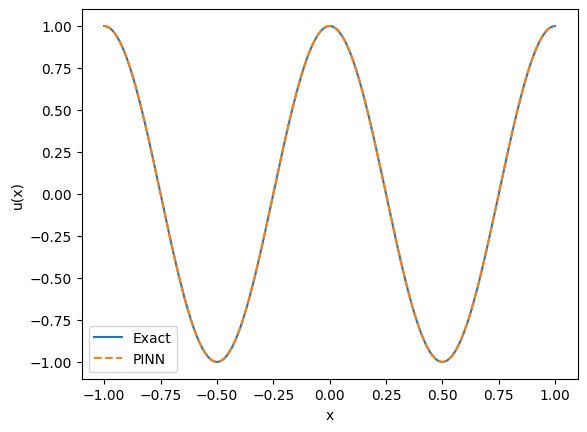

In [ ]:
geom = dde.geometry.Interval(-1,1)

def exact_solution(x):
  return np.cos(2*np.pi*x)

def pde(x,y):
  dy_xx = dde.grad.hessian(y,x)

  return dy_xx + 4*(np.pi**2)*tf.cos(2*np.pi*x)

def boundary(x,on_boundary):
  return on_boundary

bc = dde.icbc.DirichletBC(geom,lambda x:1,boundary)

data = dde.data.PDE(geom,pde,bc,num_domain=100,num_boundary=2,num_test=100)

layer_size = [1] + [50]*3 + [1]
activation = 'tanh'
initializer = 'Glorot uniform'
net = dde.nn.FNN(layer_size,activation,initializer)

model = dde.Model(data,net)
model.compile('adam',lr=0.001)

losshistory, train_state = model.train(iterations=5000)

x = np.linspace(-1,1,200)[:,None]
y_pred = model.predict(x)
y_exact = exact_solution(x)

plt.plot(x,y_exact,label='Exact')
plt.plot(x,y_pred,'--',label='PINN')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.show()

In [ ]:
pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.8 MB/s eta 0:00:00


No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)
Compiling model...
'compile' took 0.053529 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x786ab457ba60>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x786ab457ba60>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x786ab457b6a0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x786ab457b6a0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric
0         [4.00e+00, 2.41e-02, 1.51e+01]    [4.01e+00, 2.41e-02, 1.51e+01]    []  
1000      [4.45e-03, 9.14e-08, 1.68e-06]    [3.63e-03, 9.14e-08, 1.68e-06]    []  
2000      [4.55e-04, 1.24e-08, 7.29e-09]    [3.58e-04, 1.24e-08, 7.29e-09]    []  
3000      [2.43e-04, 7.10e-09, 5.82e-09]    [1.98e-04, 7.10e-09, 5.82e-09]    []  
4000      [1.49e-04, 3.07e-06, 9.70e-07]    [1.22e-04, 3.07e-06, 9.70e-07]    []  
5000      [

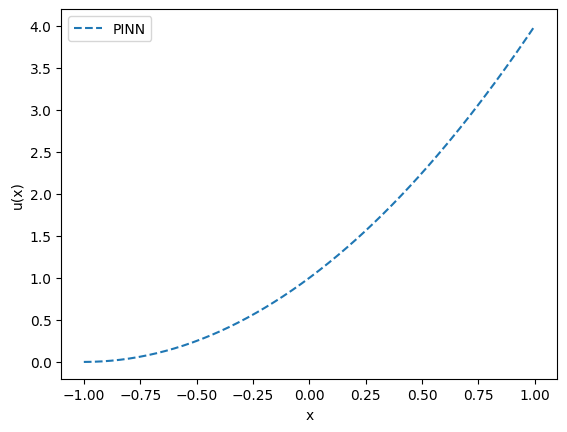

In [ ]:
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

geom = dde.geometry.Interval(-1,1)

def pde(x,y):
  dy_xx = dde.grad.hessian(y,x)
  return dy_xx - 2

def boundary_r(x, on_boundary):
    return on_boundary and dde.utils.isclose(x[0], 1)

def boundary_l(x, on_boundary):
    return on_boundary and dde.utils.isclose(x[0], -1)

bc_r = dde.icbc.NeumannBC(geom, lambda x: 4, boundary_r)
bc_l = dde.icbc.DirichletBC(geom, lambda x: 0, boundary_l)

data = dde.data.PDE(geom,pde,[bc_l,bc_r],num_domain=100,num_boundary=2,num_test=100)

layer_size = [1] + [50]*3 + [1]
activation = 'tanh'
initializer = 'Glorot uniform'
net = dde.nn.FNN(layer_size,activation,initializer)

model= dde.Model(data,net)
model.compile('adam',lr=0.001)

losshistory, train_state = model.train(iterations=5000)

x = np.linspace(-1,1,200)[:,None]
y_pred = model.predict(x)

plt.plot(x,y_pred,'--',label='PINN')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.show()

Compiling model...
'compile' took 0.004250 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [4.56e+01, 0.00e+00, 8.51e+00]    [4.73e+01, 0.00e+00, 8.51e+00]    []  
1000      [2.56e-02, 1.23e-06, 4.19e-05]    [1.91e-02, 1.23e-06, 4.19e-05]    []  
2000      [1.77e-03, 1.64e-09, 3.51e-06]    [1.62e-03, 1.64e-09, 3.51e-06]    []  
3000      [1.78e-01, 1.12e-05, 1.12e-03]    [1.77e-01, 1.12e-05, 1.12e-03]    []  
4000      [4.25e-04, 3.93e-09, 8.96e-09]    [4.75e-04, 3.93e-09, 8.96e-09]    []  
5000      [3.31e-04, 5.40e-09, 3.84e-08]    [3.83e-04, 5.40e-09, 3.84e-08]    []  

Best model at step 5000:
  train loss: 3.31e-04
  test loss: 3.83e-04
  test metric: []

'train' took 11.487638 s



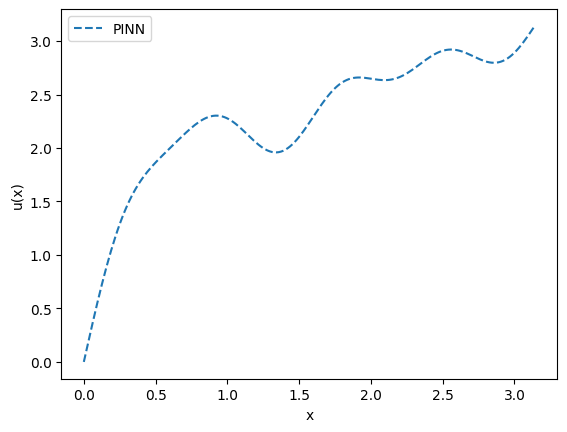

In [ ]:
geom = dde.geometry.Interval(0,np.pi)

def pde(x,y):
  dy_xx = dde.grad.hessian(y,x)
  summation = sum([i*tf.sin(i*x) for i in range(1,5)])

  return -dy_xx - summation - 8*tf.sin(8*x)

def boundary_l(x,on_boundary):
  return on_boundary and dde.utils.isclose(x[0],0)

def boundary_r(x,on_boundary):
  return on_boundary and dde.utils.isclose(x[0],np.pi)

bc_l = dde.icbc.DirichletBC(geom,lambda x:0,boundary_l)
bc_r = dde.icbc.DirichletBC(geom,lambda x:np.pi,boundary_r)

data = dde.data.PDE(geom,pde,[bc_l,bc_r],num_domain=100,num_boundary=2,num_test=100)

net = dde.nn.FNN([1]+[50]*3+[1],'tanh','Glorot uniform')

model = dde.Model(data,net)
model.compile('adam',lr=0.001)

losshistory, train_state = model.train(iterations=5000)

x_test = np.linspace(0,np.pi,200)[:,None]
y_pred = model.predict(x_test)

plt.plot(x_test,y_pred,'--',label='PINN')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.show()

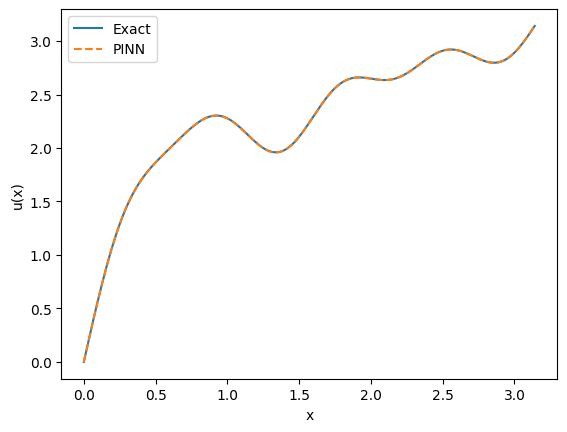

In [ ]:
def func(x):
    summation = sum([np.sin(i * x) / i for i in range(1, 5)])
    return x + summation + np.sin(8 * x) / 8

y_true = func(x_test)
plt.plot(x_test, y_true, label='Exact')
plt.plot(x_test, y_pred, '--', label='PINN')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.show()

In [1]:
pip install deepxde

In [8]:
import deepxde as dde
from deepxde.backend import tf

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
pip install --upgrade deepxde

Enter the value of A: 2
Enter the value of B: 50
Compiling model...
'compile' took 0.003049 s



Cause: could not parse the source code of <function <lambda> at 0x79973bd6e840>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Training model...

Cause: could not parse the source code of <function <lambda> at 0x79973bd6e840>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x79973bd6f880>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x79973bd6f880>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric
0         [3.04e+06, 0.00e+00, 1.79e-01]    [3.08e+06, 0.00e+00, 1.79e-01]    []  
1000      [2.37e+06, 1.68e+01, 2.08e+01]    [2.60e+06, 1.68e+01, 2.08e+01]    []  
2000      [2.35e+06, 1.69e+00, 2.14e+00]    [2.83e+06, 1.69e+00, 2.14e+00]    []  
3000      [2.34e+06, 2.26e+00, 2.35e+00]    [2.93e+06, 2.26e+00, 2.35e+00]    []  
4000      [2.34e+06, 2.44e+00, 2.44e+00]    [2.93e+06, 2.44e+00, 2.44e+00]    []  
5000      [

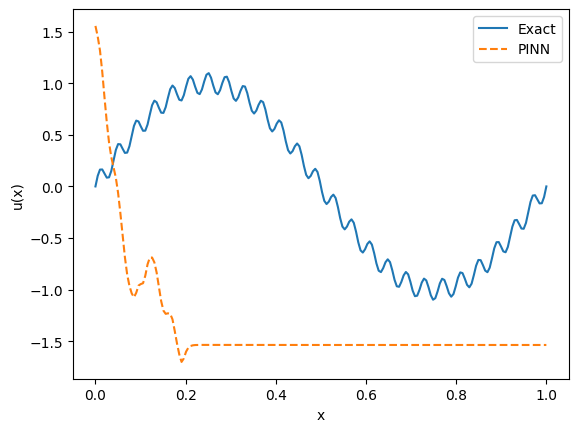

In [13]:
geom = dde.geometry.Interval(0,1)

A = int(input('Enter the value of A: '))
B = int(input('Enter the value of B: '))

def pde(x, y):
    dy_xx = dde.grad.hessian(y, x)
    return (
        dy_xx
        + (np.pi * A) ** 2 * tf.sin(np.pi * A * x)
        + 0.1 * (np.pi * B) ** 2 * tf.sin(np.pi * B * x)
    )

def boundary_l(x,on_boundary):
  return on_boundary and dde.utils.isclose(x[0],0)

def boundary_r(x,on_boundary):
  return on_boundary and dde.utils.isclose(x[0],1)

bc_l = dde.icbc.DirichletBC(geom,lambda x:0,boundary_l)
bc_r = dde.icbc.DirichletBC(geom,lambda x:0,boundary_r)

data = dde.data.PDE(geom,pde,[bc_l,bc_r],num_domain=100,num_boundary=2,num_test=100)

layer_size = [1] + [50]*3 + [1]
activation = 'tanh'
initializer = 'Glorot uniform'
net = dde.nn.FNN(layer_size,activation,initializer) #,sigmas = [1,10])

model = dde.Model(data,net)
model.compile('adam',lr=0.001,decay = ('inverse time',2000,0.9))

losshistory, train_state = model.train(iterations=5000)

def func(x):
    return np.sin(np.pi * A * x) + 0.1 * np.sin(np.pi * B * x)

X_test = np.linspace(0,1,200)[:,None]
y_pred = model.predict(X_test)
y_true = func(X_test)

plt.plot(X_test,y_true,label='Exact')
plt.plot(X_test,y_pred,'--',label='PINN')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.show()

when $$A=2$$ and $$B=50$$ model struggles to find exact solution


In [9]:
# laplace equation on a disk

!pip install deepxde
import deepxde as dde
from deepxde.backend import tf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

geom = dde.geometry.Rectangle(xmin=[0, 0], xmax=[1, 2 * np.pi])

def pde(x, y):
    dy_r = dde.grad.jacobian(y, x, i=0, j=0)
    dy_rr = dde.grad.hessian(y, x, i=0, j=0)
    dy_thetatheta = dde.grad.hessian(y, x, i=1, j=1)
    return x[:, 0:1] * dy_r + x[:, 0:1] ** 2 * dy_rr + dy_thetatheta

def boundary(x, on_boundary):
    return on_boundary and dde.utils.isclose(x[0], 1)

bc_rad = dde.icbc.DirichletBC(
    geom,
    lambda x: np.cos(x[:, 1:2]),
    lambda x, on_boundary: on_boundary and dde.utils.isclose(x[0], 1),
)

data = dde.data.PDE(
    geom, pde, bc_rad, num_domain=2540, num_boundary=80, solution=solution
)

def solution(x):
    r, theta = x[:, 0:1], x[:, 1:]
    return r * np.cos(theta)

net = dde.nn.FNN([2] + [20] * 3 + [1], "tanh", "Glorot normal")

def feature_transform(x):
    return tf.concat(
        [x[:, 0:1] * tf.sin(x[:, 1:2]), x[:, 0:1] * tf.cos(x[:, 1:2])], axis=1
    )

net.apply_feature_transform(feature_transform)

model = dde.Model(data, net)
model.compile("adam", lr=0.001)

losshistory, train_state = model.train(iterations=15000)

r = np.linspace(0,1,100)[:,None]
theta = np.linspace(0,np.pi,100)[:,None]

X,Y = np.meshgrid(r,theta)
x = np.hstack((X.flatten()[:,None],Y.flatten()[:,None]))

y_pred = model.predict(x)
y_true = solution(x)



Compiling model...
'compile' took 0.004934 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x78a7c1c11080>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x78a7c1c11080>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss              Test loss               Test metric
0         [3.37e-01, 5.72e-01]    [3.37e-01, 5.72e-01]    []  
1000      [4.88e-05, 2.23e-05]    [4.88e-05, 2.23e-05]    []  
2000      [2.40e-05, 1.33e-05]    [2.40e-05, 1.33e-05]    []  
3000      [1.36e-05, 6.80e-06]    [1.36e-05, 6.80e-06]    []  
4000      [7.84e-06, 3.28e-06]    [7.84e-06, 3.28e-06]    []  
5000      [4.22e-06, 1.50e-06]    [4.22e-06, 1.50e-06]    []  
6000      [2.31e-06, 6.54e-07]    [2.31e-06, 6.54e-07]    []  
7000 

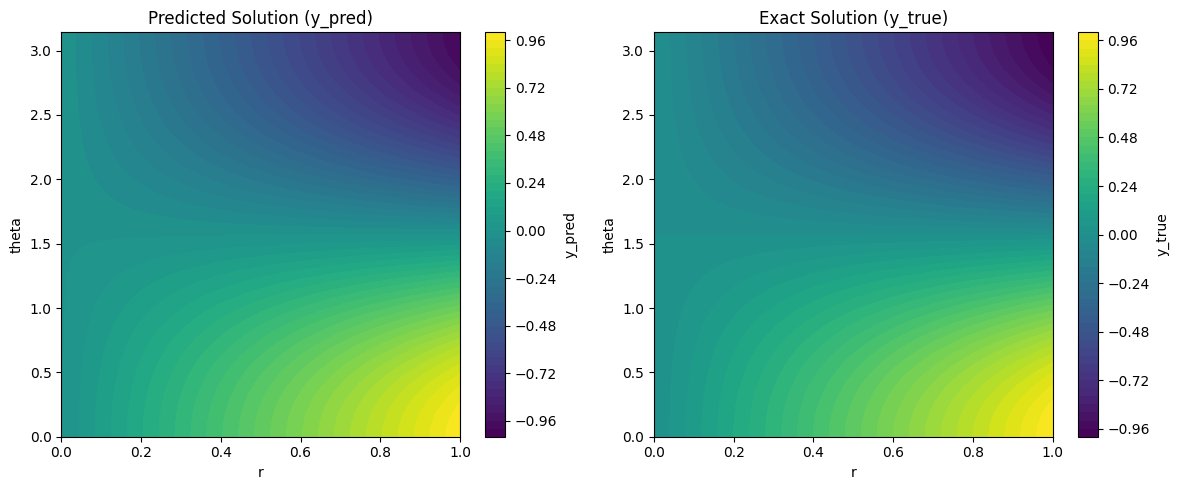

In [10]:
y_pred_reshaped = y_pred.reshape(r.shape[0], theta.shape[0])
y_true_reshaped = y_true.reshape(r.shape[0], theta.shape[0])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.contourf(X, Y, y_pred_reshaped, levels=50, cmap='viridis')
plt.colorbar(label='y_pred')
plt.xlabel('r')
plt.ylabel('theta')
plt.title('Predicted Solution (y_pred)')

plt.subplot(1, 2, 2)
plt.contourf(X, Y, y_true_reshaped, levels=50, cmap='viridis')
plt.colorbar(label='y_true')
plt.xlabel('r')
plt.ylabel('theta')
plt.title('Exact Solution (y_true)')

plt.tight_layout()
plt.show()

In [2]:
!pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 8.7 MB/s eta 0:00:00


Compiling model...
'compile' took 0.005131 s

Training model...

Step      Train loss                                            Test loss                                             Test metric
0         [3.67e-01, 0.00e+00, 1.92e-01, 4.34e-02, 6.22e-04]    [3.54e-01, 0.00e+00, 1.92e-01, 4.34e-02, 6.22e-04]    []  
1000      [6.51e-04, 4.48e-06, 3.25e-05, 4.62e-07, 1.13e-05]    [5.70e-04, 4.48e-06, 3.25e-05, 4.62e-07, 1.13e-05]    []  
2000      [2.99e-05, 1.66e-07, 1.50e-06, 8.31e-08, 1.31e-07]    [2.64e-05, 1.66e-07, 1.50e-06, 8.31e-08, 1.31e-07]    []  
3000      [9.05e-05, 2.52e-08, 4.09e-07, 4.89e-07, 3.33e-06]    [7.48e-05, 2.52e-08, 4.09e-07, 4.89e-07, 3.33e-06]    []  
4000      [1.61e-05, 1.15e-12, 1.76e-10, 1.27e-09, 1.81e-09]    [1.43e-05, 1.15e-12, 1.76e-10, 1.27e-09, 1.81e-09]    []  
5000      [1.34e-05, 1.28e-08, 1.55e-08, 8.55e-09, 8.60e-09]    [1.18e-05, 1.28e-08, 1.55e-08, 8.55e-09, 8.60e-09]    []  

Best model at step 5000:
  train loss: 1.35e-05
  test loss: 1.19e

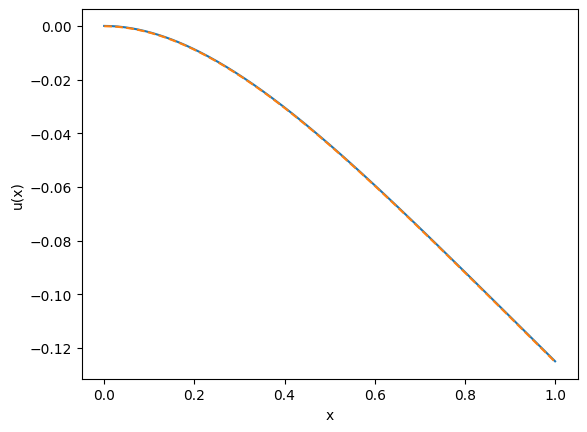

In [10]:
import deepxde as dde
from deepxde.backend import tf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

geom = dde.geometry.Interval(0,1)

def dy_xx(x,y):
  dy_xx = dde.grad.hessian(y,x)
  return dy_xx

def dy_xxx(x,y):
  dy_xxx = dde.grad.jacobian(dy_xx(x,y),x)
  return dy_xxx

def pde(x,y):
  dy_xxxx = dde.grad.hessian(dy_xx(x,y),x)
  return dy_xxxx + 1

def boundary_l(x,on_boundary):
  return on_boundary and dde.utils.isclose(x[0],0)

def boundary_r(x,on_boundary):
  return on_boundary and dde.utils.isclose(x[0],1)

bc_l1 = dde.icbc.DirichletBC(geom,lambda x:0,boundary_l)
bc_l2 = dde.icbc.NeumannBC(geom,lambda x:0,boundary_l)

bc_r1 = dde.icbc.OperatorBC(geom, lambda x,y,_:dy_xx(x,y),boundary_r)
bc_r2 = dde.icbc.OperatorBC(geom, lambda x,y,_:dy_xxx(x,y),boundary_r)

data = dde.data.PDE(geom,pde,[bc_l1,bc_l2,bc_r1,bc_r2],num_domain=100,num_boundary=2,num_test=100)

layer_size = [1] + [50]*3 + [1]
activation = 'tanh'
initializer = 'Glorot uniform'
net = dde.nn.FNN(layer_size,activation,initializer)

model = dde.Model(data,net)
model.compile('adam',lr=0.001)

losshistory, train_state = model.train(iterations=5000)

def func(x):
    return -(x ** 4) / 24 + x ** 3 / 6 - x ** 2 / 4

x_test = np.linspace(0,1,200)[:,None]
y_pred = model.predict(x_test)
y_true = func(x_test)

plt.plot(x_test,y_true,label='Exact')
plt.plot(x_test,y_pred,'--',label='PINN')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.show()
